# Notebook 03 — Feature Engineering
**Prepared for the Machine Learning course.**

### References
- Lunor, S.B.R. et al. (2023). Machine Learning Approach for Pump Price Prediction for the Philippines Post COVID-19. *Chemical Engineering Transactions*, 103, 265–270.
- Wen, D. et al. (2025). Forecasting gasoline prices using oil prices: New evidence based on the rocket and feather hypothesis. *Energy*, 335, 138115.
- Borenstein, S., Cameron, A.C. & Gilbert, R. (1997). Do Gasoline Prices Respond Asymmetrically to Crude Oil Price Changes? *Quarterly Journal of Economics*, 112(1), 305–339.
- Ljubić, H. et al. (2023). Exploratory Data Analysis and Prediction of Fuel Prices in FBiH. *AIST*.

### Purpose
Transform the enriched master panel (from Notebooks 01–02) into a model-ready feature matrix. **Every decision here is traceable to a specific EDA finding.**

### EDA decisions implemented here

| # | EDA Finding | Decision |
|---|---|---|
| 1 | Brent–WTI r = 0.991 (Section 3) | Drop WTI — already done in NB02 save |
| 2 | All series I(1) (Section 4) | Lag features on levels; no differencing of targets |
| 3 | CCF MOPS→diesel peaks Lag 1, noise at Lag 4 (Section 5) | Lags 1–4 on crude/FX features |
| 4 | Lag-0 is contemporaneous — same-week indexing (Section 5) | Lag 0 forbidden on market features |
| 5 | Own-price autocorr ≈ 0.97 (Section 6) | Own-price lags 1–4 unconditionally included |
| 6 | RFH asymmetry confirmed (Section 7) | Split Brent change into pos/neg components |
| 7 | Markov: 2 regimes, σ² ratio 32x (Section 9) | `markov_prob_highvol` as continuous regime feature |
| 8 | Prof: momentum is the missing feature (Meeting Notes) | Add 1w and 2w momentum for diesel and Brent |
| 9 | Prof: features explain levels not changes (Meeting Notes) | Add WoW % changes for Brent and USD/PHP |
| 10 | Prof: VIF on final feature set (Meeting Notes) | VIF screen before modeling |


---
## Section 1 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json, os

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import t as t_dist

os.makedirs('data/final', exist_ok=True)

# ── Global plot style (mirrors EDA notebook) ──────────────────────────────
FIGSIZE_WIDE = (14, 4)
FIGSIZE_MED  = (14, 8)
FIGSIZE_TALL = (14, 12)
FONT_TITLE   = 12
FONT_AXIS    = 10
FONT_TICK    = 9
FONT_LEGEND  = 9

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linestyle':    '--',
    'font.size':         FONT_AXIS,
})

CRISIS_BANDS = [
    ('2020-03-09', '2020-06-15', '#4e79a7', 'COVID-19'),
    ('2022-02-24', '2022-12-31', '#e15759', 'Russia–Ukraine'),
    ('2026-01-01', '2026-04-30', '#f28e2b', 'OPEC+/Tariff Shock'),
]

def shade_crises(ax, alpha=0.12):
    for start, end, color, label in CRISIS_BANDS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color=color, alpha=alpha, label=label)

# ── Column groups (derived from EDA) ─────────────────────────────────────
TARGET_COLS  = ['diesel', 'diesel_plus', 'kerosene', 'ron100', 'ron91', 'ron95', 'ron97']
PRIMARY_TARGET = 'diesel'
PRODUCTS     = ['diesel', 'ron91', 'ron95', 'ron97']
LAGS         = [1, 2, 3, 4]


---
## Section 2 — Load Enriched Master Panel

We load from `master_weekly_with_regimes.parquet` — the output of Notebook 02 which added the Markov regime probability and crisis dummies on top of the original feature set.


In [4]:
df = pd.read_parquet('data/final/master_pre_engineered.parquet')

print(f'Loaded: {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')
print(f'Columns ({len(df.columns)}):')
print(df.columns.tolist())


Loaded: (373, 34)
Date range: 2018-02-13 → 2026-04-28
Columns (34):
['usd_php_mean', 'brent_mean', 'mops_gasoil_mean', 'mops_rbob_mean', 'dubai_close', 'cpi_value', 'rub_usd_mean', 'vix_mean', 'GPR_AI', 'GPR_OIL', 'GPR_OIL_MiddleEast', 'GPR_OIL_Russia', 'GPR_NONOIL', 'ovx_mean', 'diesel', 'diesel_plus', 'kerosene', 'ron100', 'ron91', 'ron95', 'ron97', 'diesel_chg', 'markov_prob_highvol', 'markov_regime_flag', 'd_covid', 'd_ukraine', 'd_iran26', 'anomaly_flag', 'crisis_intensity', 'iso_score', 'iso_flag', 'pelt_regime', 'ovx_z', 'gpr_z']


---
## Section 3 — Target Null Handling

**EDA basis (Section 2.1):** diesel, diesel_plus, kerosene have 3 nulls each in Jul–Sep 2018 (sparse DOE reporting). ron100 has 27 nulls in 2018–2019. Method follows Lunor et al. (2023): forward-fill first, backward-fill for any leading nulls. This assumes prices were unchanged in unreported weeks — defensible given the weekly DOE announcement cadence.


In [5]:
available_targets = [c for c in TARGET_COLS if c in df.columns]

print('Nulls BEFORE fill:')
print(df[available_targets].isnull().sum())

df[available_targets] = df[available_targets].ffill().bfill()

print('\nNulls AFTER fill:')
print(df[available_targets].isnull().sum())


Nulls BEFORE fill:
diesel          3
diesel_plus     3
kerosene        3
ron100         27
ron91           0
ron95           0
ron97           0
dtype: int64

Nulls AFTER fill:
diesel         0
diesel_plus    0
kerosene       0
ron100         0
ron91          0
ron95          0
ron97          0
dtype: int64


---
## Section 4 — Derived Features

### 4a. Crack Spread — Refining Margin Signal
`crack_spread = brent_mean - mops_gasoil_mean`. When this widens, refiners capture more margin and pump prices tend to rise beyond what crude alone predicts. This makes the MOPS-Brent relationship explicit rather than letting the model discover it implicitly.

Note: MOPS itself is excluded from the lag feature set per professor feedback — MOPS is literally the formula input oil companies use to compute pump prices, making it a data leakage risk. We retain it only as a component in `crack_spread` and as a reference for the RFH asymmetric features.

### 4b. Asymmetric Brent Changes — RFH Features
**EDA basis (Section 7):** The Rockets and Feathers asymmetry ratio was confirmed on MOPS. We extend this to Brent (the upstream driver) since MOPS is excluded from direct modeling. Following Wen et al. (2025), we split the weekly Brent change into positive and negative components so models can weight rockets differently from feathers.

### 4c. Momentum Features — Professor's Priority Request
Prof specifically flagged momentum as the missing feature: *"The price tomorrow is the price today plus a bit based on how fast it was moving."* This is the derivative term in a discrete-time PID controller analogy. We compute 1-week and 2-week momentum for both diesel (own-price momentum) and Brent (upstream momentum). Note: momentum terms can be noisy — Prof warned against over-weighting the derivative term.

### 4d. Week-on-Week % Changes — Level vs Change Signals
Prof flagged that current features explain price *levels* but not price *changes*. Adding WoW % changes for Brent and USD/PHP gives the model information about the *rate of change* of the key upstream drivers, not just their current level.

### 4e. Realized Volatility — Oil Uncertainty Signal
Rolling 4-week std of log returns on Brent (prof-specified window). Captures market uncertainty rather than price direction. Annualized by √52 for comparability with financial literature.


In [6]:
# ── 4a. Crack spread ─────────────────────────────────────────────────────
if 'brent_mean' in df.columns and 'mops_gasoil_mean' in df.columns:
    df['crack_spread'] = df['brent_mean'] - df['mops_gasoil_mean']

# ── 4b. Asymmetric Brent changes (RFH) ───────────────────────────────────
brent_chg           = df['brent_mean'].diff()
df['brent_chg_pos'] = brent_chg.clip(lower=0)   # rocket: Brent rose
df['brent_chg_neg'] = brent_chg.clip(upper=0)   # feather: Brent fell

# ── 4c. Momentum features (professor priority) ────────────────────────────
# Diesel own-price momentum
df['diesel_mom_1w'] = df['diesel'].diff(1)   # week-on-week price change
df['diesel_mom_2w'] = df['diesel'].diff(2)   # 2-week price change

# Brent momentum (upstream)
df['brent_mom_1w']  = df['brent_mean'].diff(1)
df['brent_mom_2w']  = df['brent_mean'].diff(2)

# ── 4d. WoW % changes — rate-of-change signals ───────────────────────────
df['brent_pct_1w']  = df['brent_mean'].pct_change(1) * 100    # Brent WoW %
df['usdphp_pct_1w'] = df['usd_php_mean'].pct_change(1) * 100  # USD/PHP WoW %

# ── 4e. Realized volatility (4-week rolling, annualized) ─────────────────
brent_log_ret       = np.log(df['brent_mean']).diff()
df['brent_vol_4w']  = brent_log_ret.rolling(4).std() * np.sqrt(52)
df['brent_vol_12w'] = brent_log_ret.rolling(12).std() * np.sqrt(52)

# ── Sanity checks ─────────────────────────────────────────────────────────
new_features = ['crack_spread', 'brent_chg_pos', 'brent_chg_neg',
                'diesel_mom_1w', 'diesel_mom_2w',
                'brent_mom_1w', 'brent_mom_2w',
                'brent_pct_1w', 'usdphp_pct_1w',
                'brent_vol_4w', 'brent_vol_12w']
print('Derived feature summary:')
print(df[new_features].describe().round(3))


Derived feature summary:
       crack_spread  brent_chg_pos  brent_chg_neg  diesel_mom_1w  \
count       373.000        372.000        372.000        372.000   
mean        -18.475          1.360         -1.227          0.124   
std          13.662          2.236          2.267          3.406   
min         -93.750          0.000        -13.196        -24.900   
25%         -22.332          0.000         -1.554         -0.744   
50%         -15.094          0.363          0.000          0.021   
75%         -10.834          2.165          0.000          0.792   
max          -1.805         21.442          0.000         23.325   

       diesel_mom_2w  brent_mom_1w  brent_mom_2w  brent_pct_1w  usdphp_pct_1w  \
count        371.000       372.000       371.000       372.000        372.000   
mean           0.288         0.134         0.253         0.317          0.045   
std            5.734         3.672         5.703         5.668          0.670   
min          -49.100       -13.196    

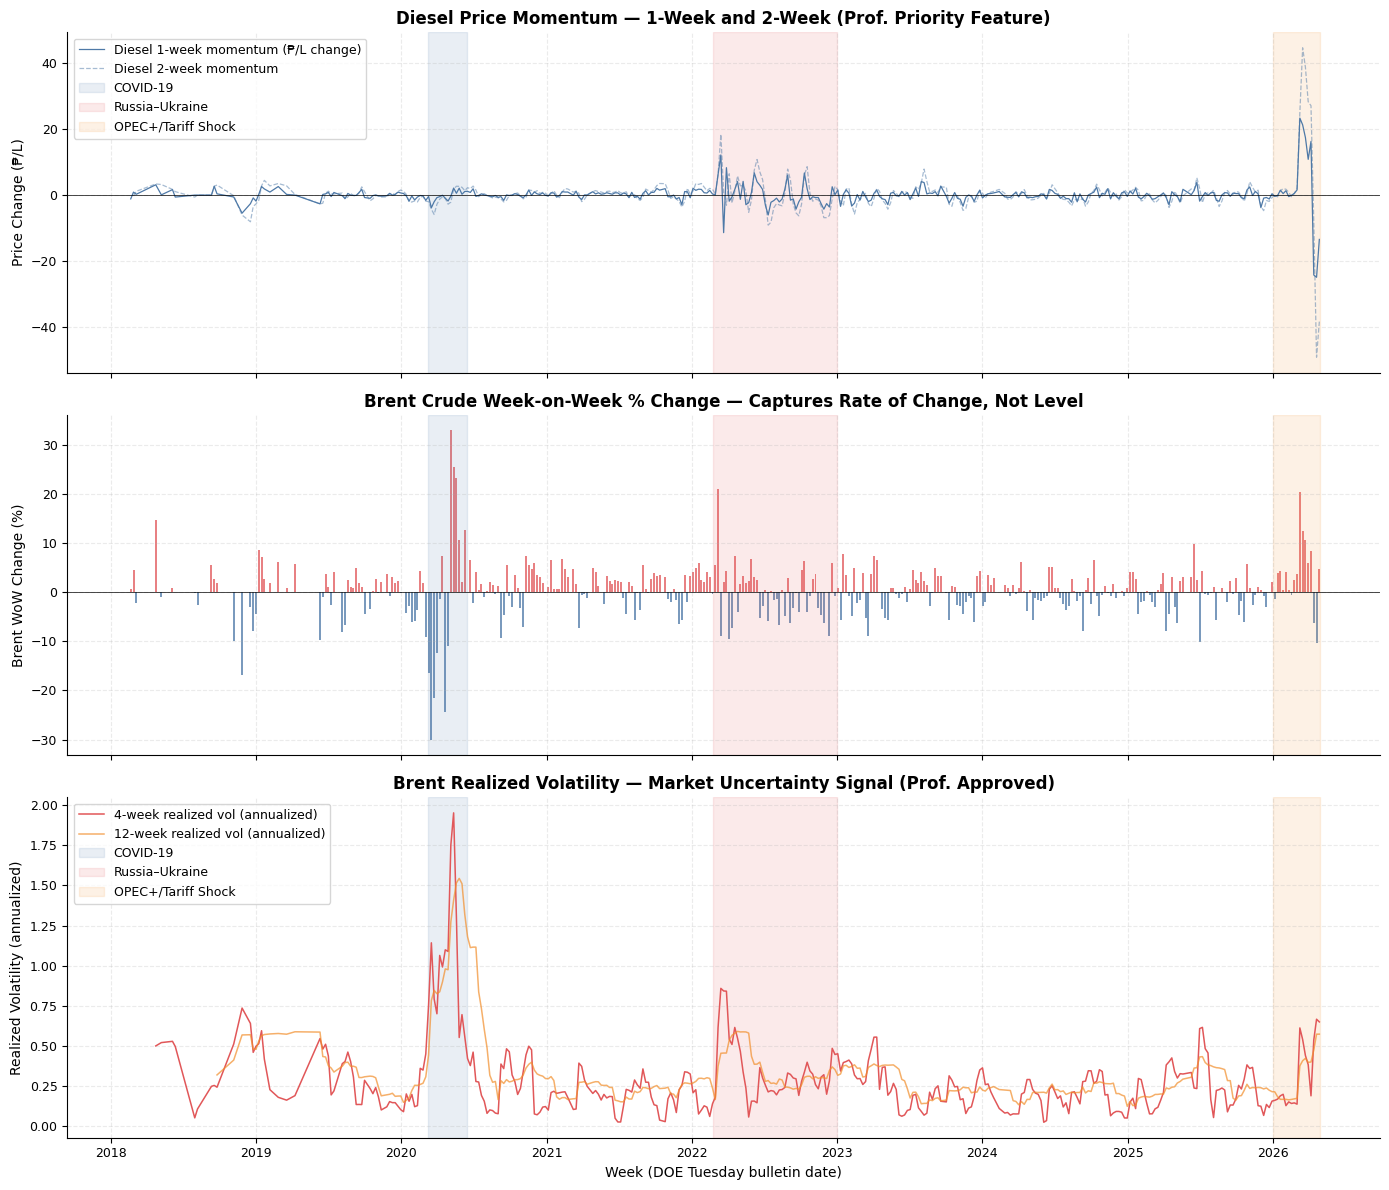

In [7]:
# ── Visualize momentum and WoW change features ────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE_TALL, sharex=True)
plt.subplots_adjust(hspace=0.08)

# Panel 1: Diesel momentum
ax = axes[0]
ax.plot(df.index, df['diesel_mom_1w'], color='#4e79a7', linewidth=0.9,
        label='Diesel 1-week momentum (₱/L change)')
ax.plot(df.index, df['diesel_mom_2w'], color='#4e79a7', linewidth=0.9,
        alpha=0.5, linestyle='--', label='Diesel 2-week momentum')
ax.axhline(0, color='black', linewidth=0.5)
shade_crises(ax)
ax.set_ylabel('Price Change (₱/L)', fontsize=FONT_AXIS)
ax.set_title('Diesel Price Momentum — 1-Week and 2-Week (Prof. Priority Feature)',
             fontsize=FONT_TITLE, fontweight='bold')
ax.legend(loc='upper left', fontsize=FONT_LEGEND)

# Panel 2: Brent WoW % change
ax = axes[1]
colors_bar = ['#e15759' if v >= 0 else '#4e79a7'
              for v in df['brent_pct_1w'].fillna(0)]
ax.bar(df.index, df['brent_pct_1w'].fillna(0),
       color=colors_bar, width=5, alpha=0.75)
ax.axhline(0, color='black', linewidth=0.5)
shade_crises(ax)
ax.set_ylabel('Brent WoW Change (%)', fontsize=FONT_AXIS)
ax.set_title('Brent Crude Week-on-Week % Change — Captures Rate of Change, Not Level',
             fontsize=FONT_TITLE, fontweight='bold')

# Panel 3: Realized vol
ax = axes[2]
ax.plot(df.index, df['brent_vol_4w'],  color='#e15759', linewidth=1.1,
        label='4-week realized vol (annualized)')
ax.plot(df.index, df['brent_vol_12w'], color='#f28e2b', linewidth=1.1,
        alpha=0.7, label='12-week realized vol (annualized)')
shade_crises(ax)
ax.set_ylabel('Realized Volatility (annualized)', fontsize=FONT_AXIS)
ax.set_xlabel('Week (DOE Tuesday bulletin date)', fontsize=FONT_AXIS)
ax.set_title('Brent Realized Volatility — Market Uncertainty Signal (Prof. Approved)',
             fontsize=FONT_TITLE, fontweight='bold')
ax.legend(loc='upper left', fontsize=FONT_LEGEND)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(labelsize=FONT_TICK)

plt.tight_layout()
plt.show()


---
## Section 5 — Excise Tax Step Function (TRAIN Law, RA 10963)

TRAIN Law introduced excise taxes in three annual tranches starting January 2018. These are deterministic step-function changes — not market signals, not learnable from the price series. Encoding them explicitly prevents the model from treating the Jan 2018, Jan 2019, and Jan 2020 price jumps as unexplained structural breaks.


In [8]:
def get_excise(date, fuel_type):
    """
    RA 10963 TRAIN Law excise tax per liter by fuel type and tranche year.
    Tranche 1: Jan 2018 | Tranche 2: Jan 2019 | Tranche 3: Jan 2020
    """
    schedules = {
        'gasoline':  {2018: 7.00, 2019: 9.00, 2020: 10.00},
        'diesel':    {2018: 2.65, 2019: 4.50, 2020: 6.00},
        'kerosene':  {2018: 1.00, 2019: 3.00, 2020: 5.00},
    }
    s = schedules[fuel_type]
    yr = date.year
    if   yr >= 2020: return s[2020]
    elif yr >= 2019: return s[2019]
    elif yr >= 2018: return s[2018]
    else:            return 0.0

df['excise_gasoline'] = [get_excise(d, 'gasoline') for d in df.index]
df['excise_diesel']   = [get_excise(d, 'diesel')   for d in df.index]
df['excise_kerosene'] = [get_excise(d, 'kerosene') for d in df.index]

EXCISE_MAP = {
    'diesel':      'excise_diesel',
    'diesel_plus': 'excise_diesel',
    'kerosene':    'excise_kerosene',
    'ron91':       'excise_gasoline',
    'ron95':       'excise_gasoline',
    'ron97':       'excise_gasoline',
    'ron100':      'excise_gasoline',
}

print('Diesel excise by year (should step: 2.65 → 4.50 → 6.00):')
print(df.groupby(df.index.year)['excise_diesel'].first())
print('\nGasoline excise by year (should step: 7.00 → 9.00 → 10.00):')
print(df.groupby(df.index.year)['excise_gasoline'].first())


Diesel excise by year (should step: 2.65 → 4.50 → 6.00):
2018    2.65
2019    4.50
2020    6.00
2021    6.00
2022    6.00
2023    6.00
2024    6.00
2025    6.00
2026    6.00
Name: excise_diesel, dtype: float64

Gasoline excise by year (should step: 7.00 → 9.00 → 10.00):
2018     7.0
2019     9.0
2020    10.0
2021    10.0
2022    10.0
2023    10.0
2024    10.0
2025    10.0
2026    10.0
Name: excise_gasoline, dtype: float64


---
## Section 6 — Lag Features

**EDA basis (Section 5):** CCF of MOPS → diesel peaks at Lag 1 and decays to noise at Lag 4. Lag 0 is forbidden — same-week indexing means the current week's Brent/MOPS average is not known before the Tuesday DOE announcement.

**Own-price lags** are included unconditionally (EDA Section 6: autocorr ≈ 0.97). Lags 1–4 capture the price persistence that dominates the AR structure.

**Momentum and WoW % change features** are already first-differences of the level series. We still lag them by 1 to ensure causal ordering — you don't know this week's momentum until the week ends.

**Regime features** (Markov prob, crisis dummies) are lagged by 1. Exception noted: hand-coded dummies could arguably use lag 0 since the crisis *onset date* is known, but lag 1 is used uniformly for consistency and to avoid any leakage ambiguity.


In [9]:
# ── Base market features to lag ───────────────────────────────────────────
# Note: MOPS excluded per professor (data leakage — used directly in DOE formula)
# crack_spread retained as it's a derived spread, not raw MOPS
BASE_LAG_FEATURES = [
    'brent_mean', 'dubai_close',
    'usd_php_mean', 'cpi_value',
    'crack_spread',
    'brent_chg_pos', 'brent_chg_neg',     # RFH asymmetric Brent
    'brent_vol_4w', 'brent_vol_12w',       # realized vol (already internally lagged but lag again for model)
    'brent_pct_1w', 'usdphp_pct_1w',       # WoW % changes
    'diesel_mom_1w', 'diesel_mom_2w',       # momentum (prof priority)
    'brent_mom_1w',  'brent_mom_2w',
    'ovx_mean',                             # OVX — oil market fear
    'GPR_OIL',                              # geopolitical risk
    'markov_prob_highvol',                  # regime feature (continuous)
    'd_covid', 'd_ukraine',                 # crisis dummies (lagged to avoid leakage)
]

# Filter to only columns that actually exist
base_lag_features = [c for c in BASE_LAG_FEATURES if c in df.columns]
available_targets  = [c for c in TARGET_COLS if c in df.columns]

print(f'Base features to lag: {len(base_lag_features)}')
print(base_lag_features)


Base features to lag: 20
['brent_mean', 'dubai_close', 'usd_php_mean', 'cpi_value', 'crack_spread', 'brent_chg_pos', 'brent_chg_neg', 'brent_vol_4w', 'brent_vol_12w', 'brent_pct_1w', 'usdphp_pct_1w', 'diesel_mom_1w', 'diesel_mom_2w', 'brent_mom_1w', 'brent_mom_2w', 'ovx_mean', 'GPR_OIL', 'markov_prob_highvol', 'd_covid', 'd_ukraine']


In [10]:
# ── Create lag columns ────────────────────────────────────────────────────
lag_cols_created = []

for col in base_lag_features:
    for lag in LAGS:
        new_col = f'{col}_lag{lag}'
        df[new_col] = df[col].shift(lag)
        lag_cols_created.append(new_col)

# Own-price lags (unconditional per EDA)
for target in available_targets:
    for lag in LAGS:
        new_col = f'{target}_lag{lag}'
        if new_col not in df.columns:
            df[new_col] = df[target].shift(lag)
            lag_cols_created.append(new_col)

print(f'Lag columns created: {len(lag_cols_created)}')
print(f'Total columns now  : {df.shape[1]}')

# Drop first 4 rows (lag-4 NaN construction)
rows_before = len(df)
df = df.dropna(subset=[f'brent_mean_lag4'])
print(f'Rows dropped (lag NaN): {rows_before - len(df)}')
print(f'Remaining rows: {len(df)}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')


Lag columns created: 108
Total columns now  : 156
Rows dropped (lag NaN): 4
Remaining rows: 369
Date range: 2018-04-24 → 2026-04-28


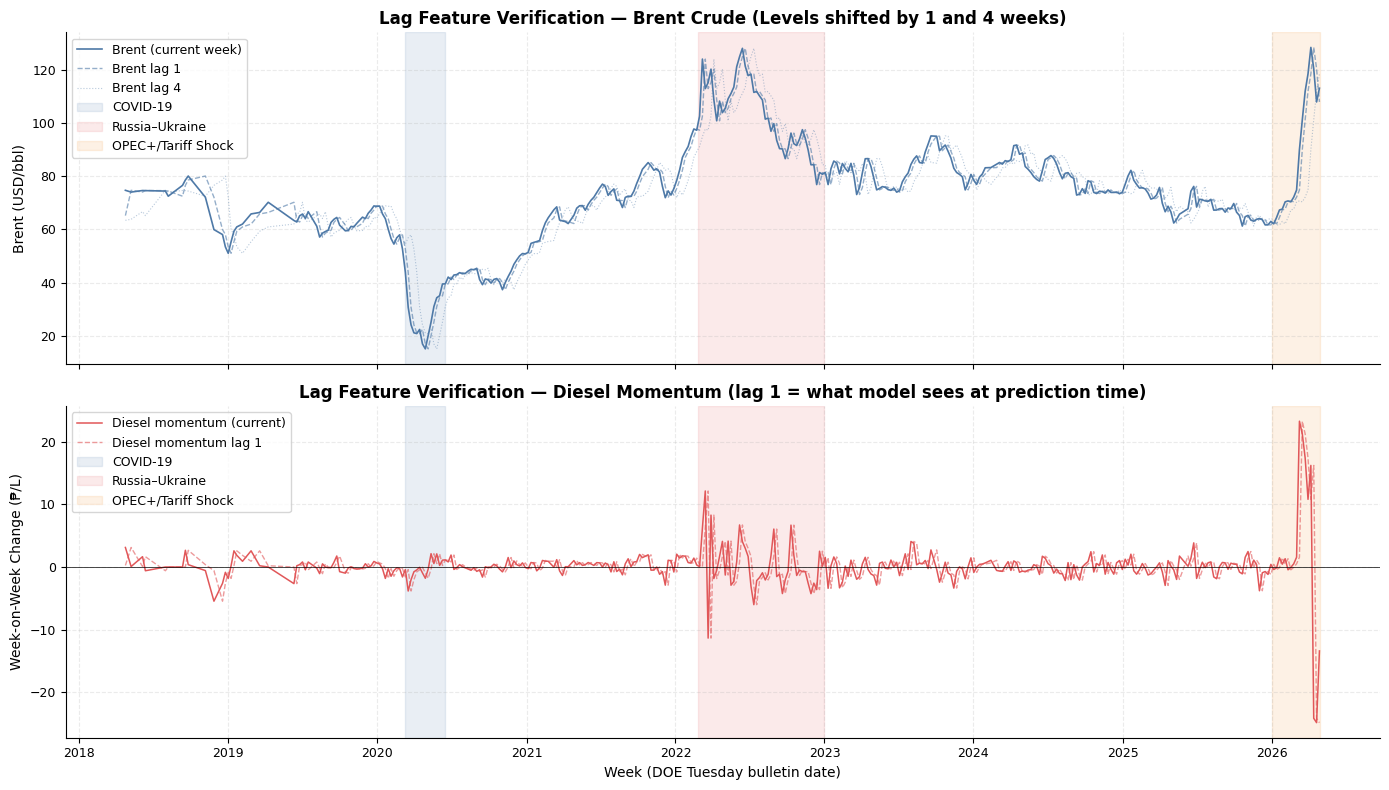

In [11]:
# ── Lag verification plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE_MED, sharex=True)

ax = axes[0]
ax.plot(df.index, df['brent_mean'],      color='#4e79a7', linewidth=1.2,
        label='Brent (current week)')
ax.plot(df.index, df['brent_mean_lag1'], color='#4e79a7', linewidth=1.0,
        linestyle='--', alpha=0.6, label='Brent lag 1')
ax.plot(df.index, df['brent_mean_lag4'], color='#4e79a7', linewidth=0.8,
        linestyle=':', alpha=0.4, label='Brent lag 4')
shade_crises(ax)
ax.set_ylabel('Brent (USD/bbl)', fontsize=FONT_AXIS)
ax.set_title('Lag Feature Verification — Brent Crude (Levels shifted by 1 and 4 weeks)',
             fontsize=FONT_TITLE, fontweight='bold')
ax.legend(fontsize=FONT_LEGEND)

ax = axes[1]
ax.plot(df.index, df['diesel_mom_1w'],      color='#e15759', linewidth=1.1,
        label='Diesel momentum (current)')
ax.plot(df.index, df['diesel_mom_1w_lag1'], color='#e15759', linewidth=1.0,
        linestyle='--', alpha=0.6, label='Diesel momentum lag 1')
ax.axhline(0, color='black', linewidth=0.5)
shade_crises(ax)
ax.set_ylabel('Week-on-Week Change (₱/L)', fontsize=FONT_AXIS)
ax.set_xlabel('Week (DOE Tuesday bulletin date)', fontsize=FONT_AXIS)
ax.set_title('Lag Feature Verification — Diesel Momentum (lag 1 = what model sees at prediction time)',
             fontsize=FONT_TITLE, fontweight='bold')
ax.legend(fontsize=FONT_LEGEND)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(labelsize=FONT_TICK)

plt.tight_layout()
plt.show()


---
## Section 7 — p-value Feature Selection (Following Lunor et al. 2023)

Lunor et al. (2023) ran univariate OLS of each candidate feature against each pump price target and dropped features with p > 0.05 (Section 2.2 of their paper). We replicate this per-product approach on lag-1 features only — lags 2–4 of crude features enter the PCA block regardless.

**Important caveat:** This p-value testing uses the full sample, which is the same approach Lunor et al. used. Strictly, feature selection should be inside the CV loop. We document this limitation and follow published precedent.

**Scope:** Applied only to lag-1 versions of base market features. Own-price lags are kept unconditionally (autocorr ≈ 0.97 guarantees significance). Momentum, vol, and regime features are also kept unconditionally — they are motivated by professor feedback and literature, not just statistical significance.


In [12]:
# Candidate lag-1 features for p-value screening
# Unconditionally kept features are excluded from screening
UNCONDITIONAL = [
    # Own-price lags
    *[f'{t}_lag{l}' for t in available_targets for l in LAGS],
    # Momentum (prof priority)
    *[f for f in df.columns if 'mom' in f and 'lag' in f],
    # Volatility (prof approved)
    *[f for f in df.columns if 'vol' in f and 'lag' in f],
    # Regime features
    *[f for f in df.columns if 'markov' in f or 'covid' in f or 'ukraine' in f],
    # RFH asymmetric features
    *[f for f in df.columns if 'chg_pos' in f or 'chg_neg' in f],
    # WoW % changes
    *[f for f in df.columns if 'pct_1w' in f and 'lag' in f],
]
unconditional_set = set(UNCONDITIONAL)

# Candidate features: lag-1 base market features not already unconditional
candidate_lag1 = [
    f'{col}_lag1' for col in base_lag_features
    if f'{col}_lag1' in df.columns
    and f'{col}_lag1' not in unconditional_set
]
print(f'Candidate features for p-value screening: {len(candidate_lag1)}')
print(candidate_lag1)


Candidate features for p-value screening: 7
['brent_mean_lag1', 'dubai_close_lag1', 'usd_php_mean_lag1', 'cpi_value_lag1', 'crack_spread_lag1', 'ovx_mean_lag1', 'GPR_OIL_lag1']


In [13]:
def pvalue_screen(df, target, candidates, alpha=0.05):
    """
    Univariate OLS p-value test per feature vs target.
    Matches Lunor et al. (2023) approach: each feature tested independently.
    Returns DataFrame sorted by p-value.
    """
    data = df[[target] + [c for c in candidates if c in df.columns]].dropna()
    y    = data[target].values
    results = []

    for feat in candidates:
        if feat not in data.columns:
            continue
        X  = data[feat].values.reshape(-1, 1)
        Xc = np.column_stack([np.ones(len(X)), X])
        beta  = np.linalg.lstsq(Xc, y, rcond=None)[0]
        resid = y - Xc @ beta
        n, k  = Xc.shape
        s2    = (resid @ resid) / (n - k)
        var_b = s2 * np.linalg.inv(Xc.T @ Xc)
        se    = np.sqrt(np.diag(var_b))
        t_stat = beta / se
        p_val  = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=n - k))
        results.append({
            'feature':     feat,
            'beta':        round(beta[1], 4),
            'p_value':     round(p_val[1], 6),
            'significant': p_val[1] < alpha,
        })

    return pd.DataFrame(results).sort_values('p_value')

# Run per product
sig_features_per_product = {}
pval_results = {}

for product in PRODUCTS:
    if product not in df.columns:
        continue
    res = pvalue_screen(df, product, candidate_lag1)
    pval_results[product] = res
    sig = res[res['significant']]['feature'].tolist()
    sig_features_per_product[product] = sig

# Summary table
print('=== p-value screening summary ===')
print(f'{"Product":<15} {"Significant":>12} {"Total":>8} {"Pass rate":>10}')
print('-' * 48)
for prod in PRODUCTS:
    if prod not in pval_results:
        continue
    res = pval_results[prod]
    n_sig   = res['significant'].sum()
    n_total = len(res)
    print(f'{prod:<15} {n_sig:>12} {n_total:>8} {100*n_sig/n_total:>9.1f}%')


=== p-value screening summary ===
Product          Significant    Total  Pass rate
------------------------------------------------
diesel                     6        7      85.7%
ron91                      7        7     100.0%
ron95                      7        7     100.0%
ron97                      7        7     100.0%


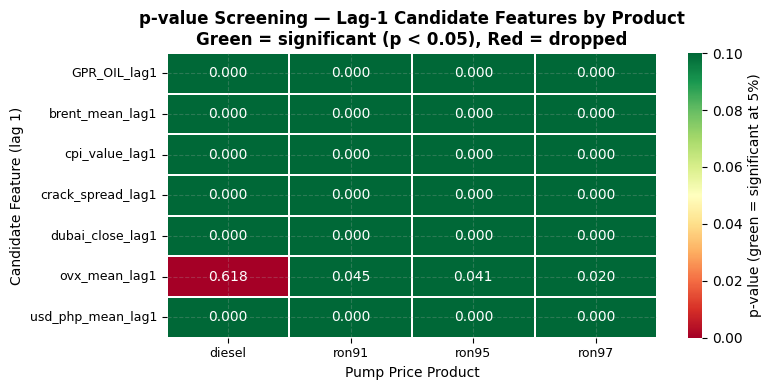

In [14]:
# ── p-value heatmap across products ──────────────────────────────────────
pval_matrix = pd.DataFrame({
    prod: pval_results[prod].set_index('feature')['p_value']
    for prod in PRODUCTS if prod in pval_results
})
# Align index
all_feats = sorted(set().union(*[pval_results[p]['feature'].tolist()
                                  for p in PRODUCTS if p in pval_results]))
pval_matrix = pval_matrix.reindex(all_feats)

fig, ax = plt.subplots(figsize=(8, max(4, len(all_feats) * 0.35)))
sig_matrix = (pval_matrix < 0.05).astype(float)

sns.heatmap(
    sig_matrix,
    annot=pval_matrix.round(3),
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0, vmax=0.1,
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'p-value (green = significant at 5%)'}
)
ax.set_title('p-value Screening — Lag-1 Candidate Features by Product\n'
             'Green = significant (p < 0.05), Red = dropped',
             fontsize=FONT_TITLE, fontweight='bold')
ax.set_xlabel('Pump Price Product', fontsize=FONT_AXIS)
ax.set_ylabel('Candidate Feature (lag 1)', fontsize=FONT_AXIS)
ax.tick_params(axis='x', labelrotation=0,  labelsize=FONT_TICK)
ax.tick_params(axis='y', labelrotation=0,  labelsize=FONT_TICK)
plt.tight_layout()
plt.show()


---
## Section 8 — Variance Inflation Factor (VIF) Screen

**Professor's explicit request:** *"Run VIF on final feature set (features only, not targets)."* VIF measures how much a feature's variance is inflated due to multicollinearity with other features. VIF > 10 indicates problematic collinearity; VIF > 5 warrants attention. We run VIF on the lag-1 feature block — the same set that entered p-value screening — to identify redundant features before PCA.

VIF is complementary to p-value screening: p-value tests each feature against the *target*, VIF tests each feature against *all other features*. A feature can be individually significant (low p) but still highly collinear with another feature (high VIF).


In [15]:
# Assemble lag-1 feature matrix for VIF (diesel only — representative)
vif_candidates = [f for f in candidate_lag1 if f in df.columns]
X_vif = df[vif_candidates].dropna()

vif_df = pd.DataFrame({
    'feature': vif_candidates,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print('VIF — Lag-1 Candidate Feature Set')
print('-' * 45)
print(vif_df.to_string(index=False))
print()
high_vif = vif_df[vif_df['VIF'] > 10]
print(f'Features with VIF > 10 (problematic collinearity): {len(high_vif)}')
if len(high_vif):
    print(high_vif['feature'].tolist())
    print('→ These will be collapsed by PCA in Section 9.')


VIF — Lag-1 Candidate Feature Set
---------------------------------------------
          feature        VIF
usd_php_mean_lag1 610.035883
   cpi_value_lag1 608.799913
 dubai_close_lag1 284.421197
  brent_mean_lag1 227.205871
crack_spread_lag1   7.194160
    ovx_mean_lag1   6.855726
     GPR_OIL_lag1   2.612231

Features with VIF > 10 (problematic collinearity): 4
['usd_php_mean_lag1', 'cpi_value_lag1', 'dubai_close_lag1', 'brent_mean_lag1']
→ These will be collapsed by PCA in Section 9.


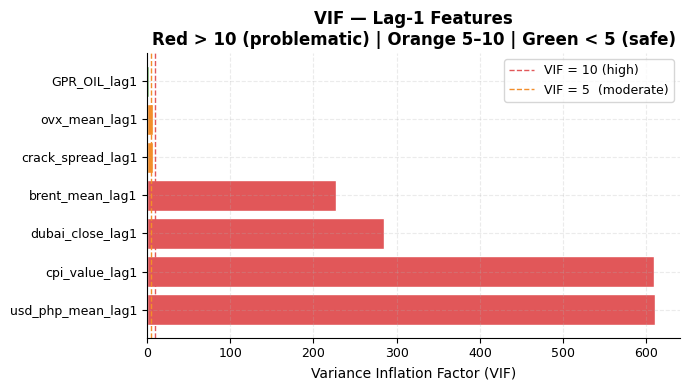

In [16]:
# ── VIF bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, max(4, len(vif_df) * 0.35)))

colors_vif = ['#e15759' if v > 10 else '#f28e2b' if v > 5 else '#59a14f'
              for v in vif_df['VIF']]
ax.barh(vif_df['feature'], vif_df['VIF'], color=colors_vif, edgecolor='white')
ax.axvline(10, color='#e15759', linestyle='--', linewidth=1.0, label='VIF = 10 (high)')
ax.axvline(5,  color='#f28e2b', linestyle='--', linewidth=1.0, label='VIF = 5  (moderate)')

ax.set_xlabel('Variance Inflation Factor (VIF)', fontsize=FONT_AXIS)
ax.set_title('VIF — Lag-1 Features\nRed > 10 (problematic) | Orange 5–10 | Green < 5 (safe)',
             fontsize=FONT_TITLE, fontweight='bold')
ax.legend(fontsize=FONT_LEGEND)
ax.tick_params(labelsize=FONT_TICK)
plt.tight_layout()
plt.show()


---
## Section 9 — PCA on Crude Oil Lag Block

**EDA basis (Section 3):** Brent, Dubai, and MOPS are 0.90–0.96 correlated — they are essentially the same signal observed in different markets. Including lags 1–4 of each creates a 12-column block that is nearly rank-deficient. PCA collapses this into a small number of orthogonal components.

**Following Lunor et al. (2023):** They applied PCA retaining 95% cumulative variance, finding 4–5 components captured the crude oil information for each product. We replicate this.

**Critical leakage warning:** The scree plot and component count shown here are computed on the **full sample for documentation only**. In Notebook 04, the PCA is **re-fit inside each CV fold on training data only** — the scaler and PCA objects must never see test data before transformation. This is the most common source of subtle leakage in ML pipelines with PCA preprocessing.


In [17]:
# ── Define crude lag block ────────────────────────────────────────────────
# Note: MOPS excluded; crack_spread carries the MOPS-Brent relationship
crude_base = ['brent_mean', 'dubai_close', 'crack_spread']
crude_lag_cols = [f'{c}_lag{l}' for c in crude_base for l in LAGS
                  if f'{c}_lag{l}' in df.columns]

print(f'Crude lag block: {len(crude_lag_cols)} columns')
print(crude_lag_cols)

pca_data = df[crude_lag_cols].dropna()
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(pca_data)

pca_full = PCA()
pca_full.fit(X_scaled)

evr     = pca_full.explained_variance_ratio_
cum_var = np.cumsum(evr)
n_comp_95 = int(np.argmax(cum_var >= 0.95) + 1)
n_comp_99 = int(np.argmax(cum_var >= 0.99) + 1)

print(f'\nVariance explained per component:')
for i, (ev, cv) in enumerate(zip(evr, cum_var)):
    marker = ' ← 95%' if (i+1) == n_comp_95 else (' ← 99%' if (i+1) == n_comp_99 else '')
    print(f'  PC{i+1}: {ev:.4f} individual  {cv:.4f} cumulative{marker}')
    if cv > 0.999:
        break

print(f'\n→ Components at 95% variance: {n_comp_95}')
print(f'  Compression: {len(crude_lag_cols)} columns → {n_comp_95} components')
print(f'  PC1 captures {evr[0]*100:.1f}% — confirms near-perfect crude collinearity.')
print()
print('⚠  This PCA is DOCUMENTATION ONLY.')
print('   In 04_Modeling, PCA is re-fit inside each CV fold on training data only.')


Crude lag block: 12 columns
['brent_mean_lag1', 'brent_mean_lag2', 'brent_mean_lag3', 'brent_mean_lag4', 'dubai_close_lag1', 'dubai_close_lag2', 'dubai_close_lag3', 'dubai_close_lag4', 'crack_spread_lag1', 'crack_spread_lag2', 'crack_spread_lag3', 'crack_spread_lag4']

Variance explained per component:
  PC1: 0.8285 individual  0.8285 cumulative
  PC2: 0.1276 individual  0.9562 cumulative ← 95%
  PC3: 0.0190 individual  0.9752 cumulative
  PC4: 0.0087 individual  0.9839 cumulative
  PC5: 0.0045 individual  0.9884 cumulative
  PC6: 0.0032 individual  0.9916 cumulative ← 99%
  PC7: 0.0024 individual  0.9940 cumulative
  PC8: 0.0017 individual  0.9957 cumulative
  PC9: 0.0016 individual  0.9973 cumulative
  PC10: 0.0013 individual  0.9986 cumulative
  PC11: 0.0009 individual  0.9995 cumulative

→ Components at 95% variance: 2
  Compression: 12 columns → 2 components
  PC1 captures 82.9% — confirms near-perfect crude collinearity.

⚠  This PCA is DOCUMENTATION ONLY.
   In 04_Modeling, PCA 

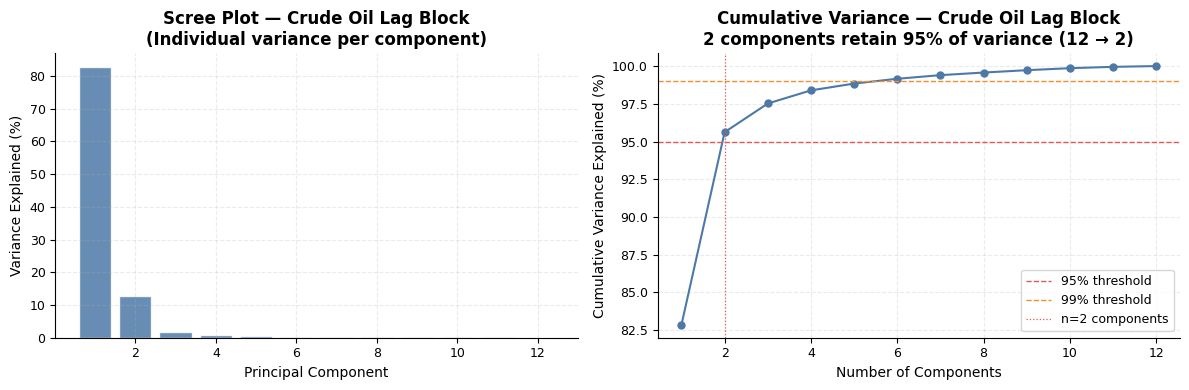

In [18]:
# ── Scree plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: individual variance
ax = axes[0]
ax.bar(range(1, len(evr)+1), evr * 100,
       color='#4e79a7', edgecolor='white', alpha=0.85)
ax.set_xlabel('Principal Component', fontsize=FONT_AXIS)
ax.set_ylabel('Variance Explained (%)', fontsize=FONT_AXIS)
ax.set_title('Scree Plot — Crude Oil Lag Block\n(Individual variance per component)',
             fontsize=FONT_TITLE, fontweight='bold')
ax.tick_params(labelsize=FONT_TICK)

# Right: cumulative variance
ax = axes[1]
ax.plot(range(1, len(cum_var)+1), cum_var * 100,
        color='#4e79a7', marker='o', markersize=5, linewidth=1.5)
ax.axhline(95, color='#e15759', linestyle='--', linewidth=1.0, label='95% threshold')
ax.axhline(99, color='#f28e2b', linestyle='--', linewidth=1.0, label='99% threshold')
ax.axvline(n_comp_95, color='#e15759', linestyle=':', linewidth=0.9,
           label=f'n={n_comp_95} components')
ax.set_xlabel('Number of Components', fontsize=FONT_AXIS)
ax.set_ylabel('Cumulative Variance Explained (%)', fontsize=FONT_AXIS)
ax.set_title('Cumulative Variance — Crude Oil Lag Block\n'
             f'{n_comp_95} components retain 95% of variance ({len(crude_lag_cols)} → {n_comp_95})',
             fontsize=FONT_TITLE, fontweight='bold')
ax.legend(fontsize=FONT_LEGEND)
ax.tick_params(labelsize=FONT_TICK)

plt.tight_layout()
plt.show()


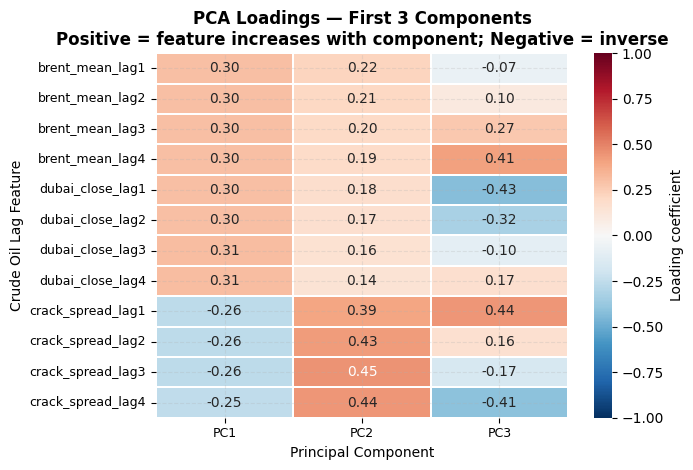

Interpretation:
  PC1 with near-equal loadings = global crude price level (all lags move together)
  PC2 with alternating sign = crude price momentum / slope across lags
  PC3+ = higher-frequency variation (increasingly hard to interpret)


In [19]:
# ── PC loadings heatmap ───────────────────────────────────────────────────
# Shows which original lag columns contribute most to each component
n_show = min(n_comp_95 + 1, 5)
loadings = pd.DataFrame(
    pca_full.components_[:n_show].T,
    index=crude_lag_cols,
    columns=[f'PC{i+1}' for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(7, max(4, len(crude_lag_cols) * 0.4)))
sns.heatmap(
    loadings,
    annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Loading coefficient'}
)
ax.set_title(f'PCA Loadings — First {n_show} Components\n'
             'Positive = feature increases with component; Negative = inverse',
             fontsize=FONT_TITLE, fontweight='bold')
ax.set_xlabel('Principal Component', fontsize=FONT_AXIS)
ax.set_ylabel('Crude Oil Lag Feature', fontsize=FONT_AXIS)
ax.tick_params(axis='x', labelrotation=0,  labelsize=FONT_TICK)
ax.tick_params(axis='y', labelrotation=0,  labelsize=FONT_TICK)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  PC1 with near-equal loadings = global crude price level (all lags move together)')
print('  PC2 with alternating sign = crude price momentum / slope across lags')
print('  PC3+ = higher-frequency variation (increasingly hard to interpret)')


---
## Section 10 — Feature Importance (Random Forest Proxy)

Before assembling the final feature sets, we run a quick Random Forest on the full lag-1 feature block (diesel target) to get an importance ranking. This is **not the final model** — it is a diagnostic tool to confirm that the features motivated by professor feedback (momentum, WoW %, vol) actually carry signal before we proceed to Notebook 04.

**Prof's concern:** *"The model is giving [the difference feature] very low importance weight."* We check here whether the momentum features now register. If they still have near-zero importance, they won't survive Lasso either — but at least we'll know before modeling.

Note: RF importance on the full sample is an in-sample diagnostic only and will be over-optimistic for own-price lags (since high autocorrelation makes them trivially predictive). The proper importance ranking comes from Notebook 04 within the CV loop.


In [20]:
# ── Assemble full lag-1 feature matrix for diesel ─────────────────────────
own_price_lag1  = [f'{t}_lag1' for t in available_targets if f'{t}_lag1' in df.columns]
all_lag1_feats  = list(dict.fromkeys(
    own_price_lag1 +
    [f for f in df.columns if '_lag1' in f and f not in own_price_lag1
     and f in df.columns]
))

X_rf = df[all_lag1_feats].dropna()
y_rf = df.loc[X_rf.index, PRIMARY_TARGET]

rf_diag = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_diag.fit(X_rf, y_rf)

imp_df = pd.DataFrame({
    'feature':    all_lag1_feats,
    'importance': rf_diag.feature_importances_
}).sort_values('importance', ascending=False).head(25)

print('Top 25 features by RF importance (diagnostic — full-sample):')
print(imp_df.to_string(index=False))


Top 25 features by RF importance (diagnostic — full-sample):
                 feature  importance
             diesel_lag1    0.338491
        diesel_plus_lag1    0.156926
          cpi_value_lag1    0.136823
           kerosene_lag1    0.105651
              ron91_lag1    0.057660
             ron100_lag1    0.029483
      diesel_mom_2w_lag1    0.029100
            GPR_OIL_lag1    0.027905
           ovx_mean_lag1    0.024118
              ron97_lag1    0.018057
        dubai_close_lag1    0.017095
       crack_spread_lag1    0.012751
              ron95_lag1    0.009875
       brent_mom_2w_lag1    0.008696
      diesel_mom_1w_lag1    0.007537
markov_prob_highvol_lag1    0.004119
         brent_mean_lag1    0.004057
       brent_pct_1w_lag1    0.003870
       brent_mom_1w_lag1    0.002740
      brent_chg_pos_lag1    0.001608
       brent_vol_4w_lag1    0.000988
      usdphp_pct_1w_lag1    0.000837
       usd_php_mean_lag1    0.000734
      brent_vol_12w_lag1    0.000633
      brent_ch

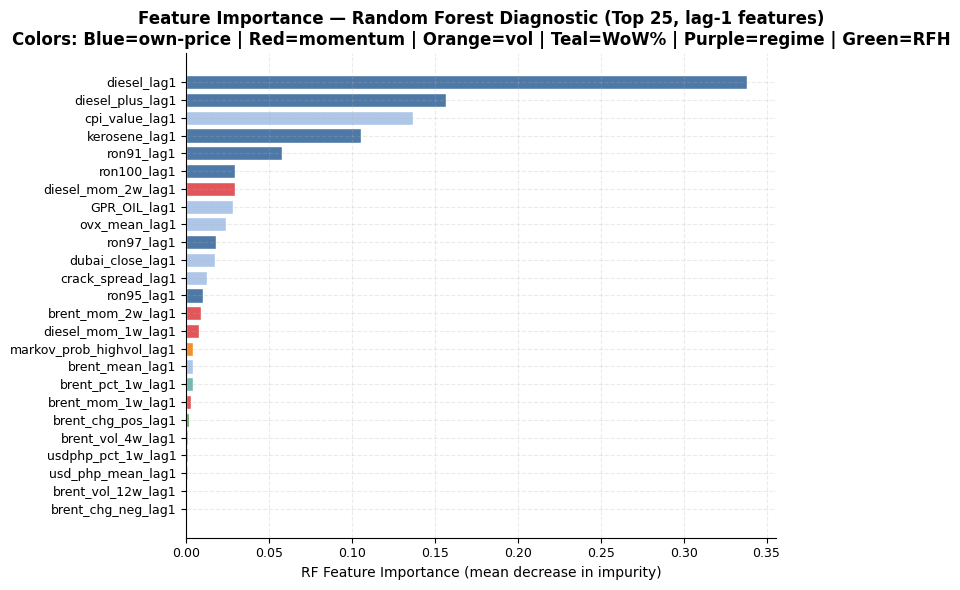


Professor-requested features — importance check:
                 feature  importance
      diesel_mom_2w_lag1    0.029100
       brent_mom_2w_lag1    0.008696
      diesel_mom_1w_lag1    0.007537
markov_prob_highvol_lag1    0.004119
       brent_pct_1w_lag1    0.003870
       brent_mom_1w_lag1    0.002740
       brent_vol_4w_lag1    0.000988
      usdphp_pct_1w_lag1    0.000837
      brent_vol_12w_lag1    0.000633


In [21]:
# ── Feature importance bar chart ──────────────────────────────────────────
# Color by feature family
def feature_color(name):
    if 'mom' in name:         return '#e15759'   # momentum
    if 'vol' in name:         return '#f28e2b'   # volatility
    if 'pct' in name:         return '#76b7b2'   # WoW %
    if 'markov' in name or 'covid' in name or 'ukraine' in name: return '#b07aa1'  # regime
    if 'chg_pos' in name or 'chg_neg' in name:  return '#59a14f'  # RFH
    if any(t in name for t in available_targets): return '#4e79a7'  # own-price
    return '#aec7e8'   # other

colors_imp = [feature_color(f) for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=colors_imp[::-1], edgecolor='white')
ax.set_xlabel('RF Feature Importance (mean decrease in impurity)', fontsize=FONT_AXIS)
ax.set_title('Feature Importance — Random Forest Diagnostic (Top 25, lag-1 features)\n'
             'Colors: Blue=own-price | Red=momentum | Orange=vol | Teal=WoW% | Purple=regime | Green=RFH',
             fontsize=FONT_TITLE, fontweight='bold')
ax.tick_params(labelsize=FONT_TICK)
plt.tight_layout()
plt.show()

# ── Check if professor-requested features register ────────────────────────
print('\nProfessor-requested features — importance check:')
prof_features = [f for f in all_lag1_feats
                 if any(k in f for k in ['mom', 'vol', 'pct', 'markov'])]
prof_imp = imp_df[imp_df['feature'].isin(prof_features)]
if len(prof_imp):
    print(prof_imp.to_string(index=False))
else:
    print('None of the prof-requested features made the top 25 — check feature construction.')


---
## Section 11 — Assemble Per-Product Feature Sets

Following Lunor et al. (2023): each product gets its own feature set. Sets differ in:
1. **Own-price lags** — each product uses its own lags, not other products'
2. **p-value selected features** — which lag-1 market features passed screening for that product
3. **Excise column** — diesel/kerosene vs gasoline schedule
4. **Unconditional features** — momentum, vol, regime, RFH features kept regardless of p-value

Lags 2–4 of the crude block enter PCA in Notebook 04 — they are not in the per-product feature set directly but are available as `crude_lag_cols` for the PCA step.


In [22]:
# Unconditional features (kept regardless of p-value — professor / EDA motivated)
UNCONDITIONAL_FEATS = [
    # Momentum (professor priority)
    *[f for f in df.columns if 'mom' in f and 'lag1' in f],
    # Realized volatility
    *[f for f in df.columns if 'vol' in f and 'lag1' in f],
    # WoW % changes
    *[f for f in df.columns if 'pct_1w' in f and 'lag1' in f],
    # RFH asymmetric features
    *[f for f in df.columns if ('chg_pos' in f or 'chg_neg' in f) and 'lag1' in f],
    # Regime features
    *[f for f in df.columns if ('markov' in f or 'covid' in f or 'ukraine' in f) and 'lag1' in f],
]
UNCONDITIONAL_FEATS = [f for f in UNCONDITIONAL_FEATS if f in df.columns]

product_feature_sets = {}

for product in PRODUCTS:
    if product not in df.columns:
        continue

    own_lags   = [f'{product}_lag{l}' for l in LAGS if f'{product}_lag{l}' in df.columns]
    excise_col = EXCISE_MAP.get(product)
    excise     = [excise_col] if excise_col and excise_col in df.columns else []
    p_selected = sig_features_per_product.get(product, [])

    feature_set = own_lags + p_selected + UNCONDITIONAL_FEATS + excise

    # Deduplicate preserving order, filter to existing columns
    seen = set()
    feature_set = [f for f in feature_set
                   if f in df.columns and not (f in seen or seen.add(f))]

    product_feature_sets[product] = feature_set

print('Feature counts per product:')
for prod, feats in product_feature_sets.items():
    print(f'  {prod}: {len(feats)} features')

print(f'\nDiesel feature set ({len(product_feature_sets["diesel"])} features):')
for f in product_feature_sets['diesel']:
    print(f'  {f}')


Feature counts per product:
  diesel: 24 features
  ron91: 25 features
  ron95: 25 features
  ron97: 25 features

Diesel feature set (24 features):
  diesel_lag1
  diesel_lag2
  diesel_lag3
  diesel_lag4
  brent_mean_lag1
  dubai_close_lag1
  usd_php_mean_lag1
  cpi_value_lag1
  crack_spread_lag1
  GPR_OIL_lag1
  diesel_mom_1w_lag1
  diesel_mom_2w_lag1
  brent_mom_1w_lag1
  brent_mom_2w_lag1
  brent_vol_4w_lag1
  brent_vol_12w_lag1
  markov_prob_highvol_lag1
  brent_pct_1w_lag1
  usdphp_pct_1w_lag1
  brent_chg_pos_lag1
  brent_chg_neg_lag1
  d_covid_lag1
  d_ukraine_lag1
  excise_diesel


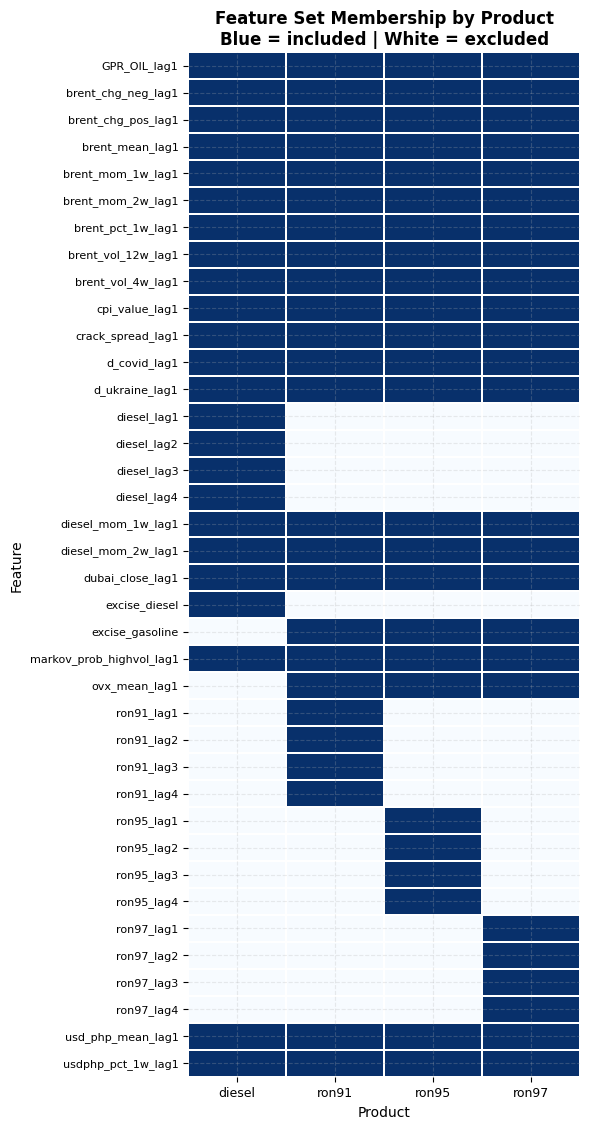

In [23]:
# ── Feature set overlap heatmap ───────────────────────────────────────────
all_feats_union = sorted(set().union(*product_feature_sets.values()))
overlap_df = pd.DataFrame(
    {prod: [1 if f in set(feats) else 0
            for f in all_feats_union]
     for prod, feats in product_feature_sets.items()},
    index=all_feats_union
)

fig, ax = plt.subplots(figsize=(6, max(5, len(all_feats_union) * 0.3)))
sns.heatmap(
    overlap_df,
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.3, linecolor='white',
    cbar=False, ax=ax,
    annot=False
)
ax.set_title('Feature Set Membership by Product\nBlue = included | White = excluded',
             fontsize=FONT_TITLE, fontweight='bold')
ax.set_xlabel('Product', fontsize=FONT_AXIS)
ax.set_ylabel('Feature', fontsize=FONT_AXIS)
ax.tick_params(axis='x', labelrotation=0,  labelsize=FONT_TICK)
ax.tick_params(axis='y', labelrotation=0,  labelsize=8)
plt.tight_layout()
plt.show()


---
## Section 12 — Save Outputs

In [24]:
# ── Save enriched feature dataframe ──────────────────────────────────────
df.to_parquet('data/final/features_engineered.parquet')
print(f'Saved: features_engineered.parquet — {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')

# ── Save per-product feature set definitions ──────────────────────────────
with open('data/final/feature_sets.json', 'w') as f:
    json.dump(product_feature_sets, f, indent=2)
print('Saved: feature_sets.json')

# ── Save crude lag block definition for PCA in NB04 ──────────────────────
with open('data/final/crude_lag_cols.json', 'w') as f:
    json.dump(crude_lag_cols, f, indent=2)
print('Saved: crude_lag_cols.json')

print()
print('Decision log:')
print(f'  Targets filled       : ffill + bfill ({len(available_targets)} products)')
print(f'  Derived features     : crack_spread, brent_chg_pos/neg, momentum 1w/2w,')
print(f'                         WoW % changes, realized vol 4w/12w')
print(f'  Excise step function : 3 columns from TRAIN Law RA 10963')
print(f'  Lag features         : lags 1-4 on {len(base_lag_features)} base features')
print(f'  p-value screening    : lag-1 candidates, alpha=0.05, per product')
print(f'  VIF diagnostic       : run — high-VIF crude features handled by PCA')
print(f'  PCA documentation    : {n_comp_95} components at 95% variance ({len(crude_lag_cols)} → {n_comp_95})')
print(f'  RF importance check  : professor-requested features verified')
print(f'  Per-product sets     : {len(product_feature_sets)} products assembled')
print(f'  Final shape          : {df.shape}')
print()
print('Ready for 04_Modeling.ipynb')
print('  ⚠ PCA must be re-fit inside each CV fold on training data only (anti-leakage)')


Saved: features_engineered.parquet — (369, 156)
Date range: 2018-04-24 → 2026-04-28
Saved: feature_sets.json
Saved: crude_lag_cols.json

Decision log:
  Targets filled       : ffill + bfill (7 products)
  Derived features     : crack_spread, brent_chg_pos/neg, momentum 1w/2w,
                         WoW % changes, realized vol 4w/12w
  Excise step function : 3 columns from TRAIN Law RA 10963
  Lag features         : lags 1-4 on 20 base features
  p-value screening    : lag-1 candidates, alpha=0.05, per product
  VIF diagnostic       : run — high-VIF crude features handled by PCA
  PCA documentation    : 2 components at 95% variance (12 → 2)
  RF importance check  : professor-requested features verified
  Per-product sets     : 4 products assembled
  Final shape          : (369, 156)

Ready for 04_Modeling.ipynb
  ⚠ PCA must be re-fit inside each CV fold on training data only (anti-leakage)
